# Session 49: Simple Linear regression

[Watch Here](https://youtu.be/aEPoLeS6UMM?si=sMJ_S3J2Y4_3qhZ3)

## Simple Linear regression

In [62]:
# Importing basic libraries for numerical computation, data framing, and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [63]:
# Load the placement dataset from Google Drive into a pandas DataFrame
df = pd.read_csv('/content/drive/MyDrive/Datasets/Week 23/placement.csv')

In [64]:
# Preview the first 5 records of the loaded dataframe to check the features and target variable structure
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package(in lpa)')

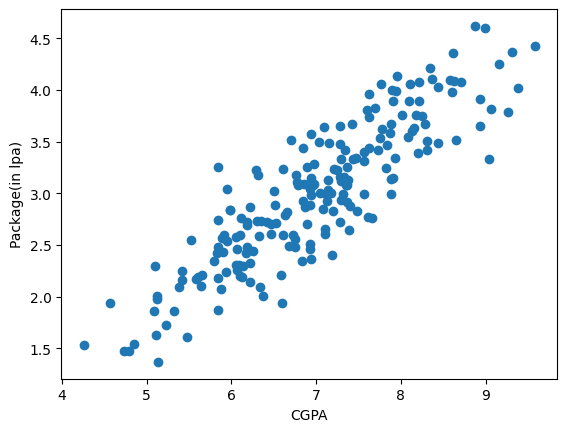

In [65]:
# Create a scatter plot to visualize the relationship between CGPA and Package (LPA)
plt.scatter(df['cgpa'], df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [66]:
# Separate the independent feature (CGPA) as X and the dependent target (Package) as y
X = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [67]:
# Display the independent feature (X) and target variable (y) to verify
print('Independent feature \n', X)
print('Dependent target \n', y)

Independent feature 
      cgpa
0    6.89
1    5.12
2    7.82
3    7.42
4    6.94
..    ...
195  6.93
196  5.89
197  7.21
198  7.63
199  6.22

[200 rows x 1 columns]
Dependent target 
 0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64


In [68]:
# Split the dataset into training (80%) and testing (20%) sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [69]:
# Import the Linear Regression model class from scikit-learn
from sklearn.linear_model import LinearRegression

In [70]:
# Instantiate the Linear Regression model object
lr = LinearRegression()

In [71]:
# Fit (train) the Linear Regression model on the training data
lr.fit(X_train, y_train)

LinearRegression()

In [72]:
# Display the test input features (X_test) and testing target values (y_test) to verify testing data split
print('Testing input features \n', X_test)
print('Testing target values \n', y_test)

Testing input features 
      cgpa
112  8.58
29   7.15
182  5.88
199  6.22
193  4.57
85   4.79
10   5.32
54   6.86
115  8.35
35   6.87
12   8.94
92   7.90
13   6.93
126  5.91
174  7.32
2    7.82
44   5.09
3    7.42
113  6.94
14   7.73
23   6.19
25   7.28
6    6.73
134  7.20
165  8.21
173  6.75
45   7.87
65   7.60
48   8.63
122  5.12
178  8.15
64   7.36
9    8.31
57   6.60
78   6.59
71   7.47
128  7.93
176  6.29
131  6.37
53   6.47
Testing target values 
 112    4.10
29     3.49
182    2.08
199    2.33
193    1.94
85     1.48
10     1.86
54     3.09
115    4.21
35     2.87
12     3.65
92     4.00
13     2.89
126    2.60
174    2.99
2      3.25
44     1.86
3      3.67
113    2.37
14     3.42
23     2.48
25     3.65
6      2.60
134    2.83
165    4.08
173    2.56
45     3.58
65     3.81
48     4.09
122    2.01
178    3.63
64     2.92
9      3.51
57     1.94
78     2.21
71     3.34
128    3.34
176    3.23
131    2.01
53     2.61
Name: package, dtype: float64


In [73]:
# Reshape a single input value into a 2D array to satisfy the scikit-learn API format and predict its package outcome
# Predict the package for the first test sample by reshaping it into 2D format
lr.predict(X_test.iloc[0].values.reshape(1, 1))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.89111601])

Text(0, 0.5, 'Package(in lpa)')

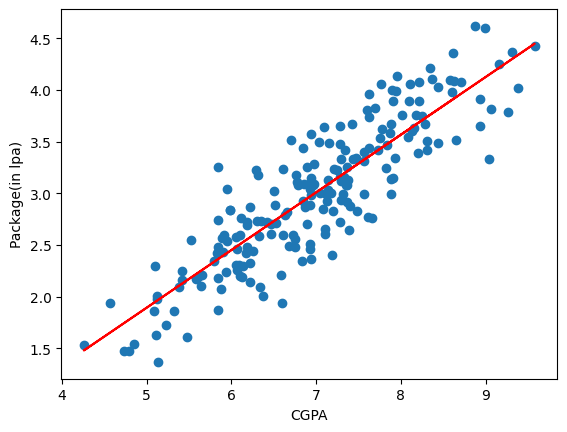

In [74]:
# Overlay the calculated linear regression line in red onto the scatter plot of actual data samples
# Plot the training data points along with the red regression line representing the model's predictions
plt.scatter(df['cgpa'], df['package'])
plt.plot(X_train, lr.predict(X_train), color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [75]:
# Extract the coefficient (slope 'm') of the regression line
m = lr.coef_

In [76]:
# Extract the intercept ('b') of the regression line
b = lr.intercept_

In [77]:
# Manually calculate the predicted package for CGPA = 8.58 using the line equation (y = mx + b)
print('Predicted package ->', m * 8.58 + b)

Predicted package -> [3.89111601]


In [78]:
# Manually calculate the predicted package for CGPA = 9.5 using the line equation (y = mx + b)
print('Predicted package ->', m * 9.5 + b)

Predicted package -> [4.40443183]


In [79]:
# Manually calculate the predicted package for an out-of-bounds CGPA = 100 to show the line formula calculation
print('Predicted package ->', m * 100 + b)

Predicted package -> [54.89908542]


## How to find `m` and `b`

In [80]:
# Define a custom Linear Regression class from scratch using mathematical formulations for closed-form OLS
class MeraLR:

    def __init__(self):
        self.m = None
        self.b = None

    def fit(self, X_train, y_train):

        num = 0
        den = 0

        # Iterate through the elements to calculate the numerator and denominator of the slope (m) formula
        for i in range(X_train.shape[0]):

            num = num + ((X_train[i] - X_train.mean()) * (y_train[i] - y_train.mean()))
            den = den + ((X_train[i] - X_train.mean()) * (X_train[i] - X_train.mean()))

        self.m = num / den
        self.b = y_train.mean() - (self.m * X_train.mean())
        print(self.m)
        print(self.b)

    def predict(self, X_test):

        print(X_test)

        # Calculate and return the predicted values using the linear equation y = mx + b
        return self.m * X_test + self.b

In [81]:
# Read the placement dataset again to demonstrate the usage of the custom scratch-built linear regression class
df = pd.read_csv('/content/drive/MyDrive/Datasets/Week 23/placement.csv')

In [82]:
# View the top 5 records of the loaded dataframe to confirm proper reloading
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [83]:
# Extract the 1D arrays of input feature and target values from the dataframe
X = df.iloc[:,0].values
y = df.iloc[:,1].values

In [84]:
# Display the extracted 1D numpy arrays to inspect the datasets
print('Input features \n', X)
print('Target values \n', y)

Input features 
 [6.89 5.12 7.82 7.42 6.94 7.89 6.73 6.75 6.09 8.31 5.32 6.61 8.94 6.93
 7.73 7.25 6.84 5.38 6.94 7.48 7.28 6.85 6.14 6.19 6.53 7.28 8.31 5.42
 5.94 7.15 7.36 8.1  6.96 6.35 7.34 6.87 5.99 5.9  8.62 7.43 9.38 6.89
 5.95 7.66 5.09 7.87 6.07 5.84 8.63 8.87 9.58 9.26 8.37 6.47 6.86 8.2
 5.84 6.6  6.92 7.56 5.61 5.48 6.34 9.16 7.36 7.6  5.11 6.51 7.56 7.3
 5.79 7.47 7.78 8.44 6.85 6.97 6.94 8.99 6.59 7.18 7.63 6.1  5.58 8.44
 4.26 4.79 7.61 8.09 4.73 6.42 7.11 6.22 7.9  6.79 5.83 6.63 7.11 5.98
 7.69 6.61 7.95 6.71 5.13 7.05 7.62 6.66 6.13 6.33 7.76 7.77 8.18 5.42
 8.58 6.94 5.84 8.35 9.04 7.12 7.4  7.39 5.23 6.5  5.12 5.1  6.06 7.33
 5.91 6.78 7.93 7.29 6.68 6.37 5.84 6.05 7.2  6.1  5.64 7.14 7.91 7.19
 7.91 6.76 6.93 4.85 6.17 5.84 6.07 5.66 7.57 8.28 6.3  6.12 7.37 7.94
 7.08 6.98 7.38 6.47 5.95 8.71 7.13 7.3  5.53 8.93 9.06 8.21 8.6  8.13
 8.65 9.31 6.22 8.01 6.93 6.75 7.32 7.04 6.29 7.09 8.15 7.14 6.19 8.22
 5.88 7.28 7.88 6.31 7.84 6.26 7.35 8.11 6.19 7.28 8.25 4.57 7

In [85]:
# Partition the 1D arrays into training (80%) and testing (20%) splits using a random seed
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [86]:
# Check the dimensions of the training input feature dataset
X_train.shape

(160,)

In [87]:
# Instantiate the custom MeraLR class
lr = MeraLR()

In [88]:
# Run the fit method of the custom class to calculate the slope and intercept analytically
lr.fit(X_train, y_train)

0.5579519734250721
-0.8961119222429152


In [89]:
# Output the number of samples present in the training set
X_train.shape[0]

160

In [90]:
# Retrieve the first value in the training dataset
X_train[0]

np.float64(7.14)

In [91]:
# Calculate the average value of the training features
X_train.mean()

np.float64(6.989937500000001)

In [92]:
# Retrieve the first value in the testing dataset
X_test[0]

np.float64(8.58)

In [93]:
# Make a prediction on the first test sample using the custom class predict formulation and print the output
print(lr.predict(X_test[0]))

8.58
3.891116009744203


## Regression Metrics

In [94]:
# Reload the placement dataset to begin demonstrating model evaluation and regression metrics
df = pd.read_csv('/content/drive/MyDrive/Datasets/Week 23/placement.csv')

In [95]:
# Show the head of the reloaded dataframe
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [96]:
# Check the total rows and columns of the placement dataset
df.shape

(200, 2)

Text(0, 0.5, 'Package(in lpa)')

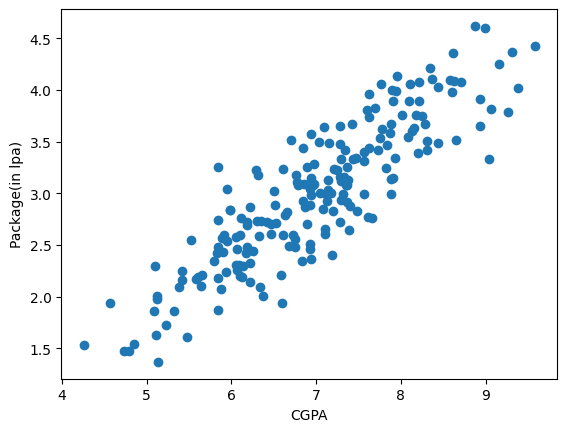

In [97]:
# Create a scatter plot of the actual data points to visually analyze their dispersion
plt.scatter(df['cgpa'], df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [98]:
# Separate the dataset into feature matrix X (2D) and target vector y
X = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [99]:
# Print the separated inputs and target datasets to ensure shape compliance
print('Input features \n', X)
print('Target values \n', y)

Input features 
      cgpa
0    6.89
1    5.12
2    7.82
3    7.42
4    6.94
..    ...
195  6.93
196  5.89
197  7.21
198  7.63
199  6.22

[200 rows x 1 columns]
Target values 
 0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64


In [105]:
# Partition the reloaded dataset into train and test groups using train_test_split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [106]:
# Import the standard linear regression class from sklearn
from sklearn.linear_model import LinearRegression

In [107]:
# Create a new instance of the Linear Regression model
lr = LinearRegression()

In [108]:
# Train the regression model with the newly split training group
lr.fit(X_train, y_train)

LinearRegression()

In [109]:
# Print representation of the trained LinearRegression object
LinearRegression()

LinearRegression()

Text(0, 0.5, 'Package(in lpa)')

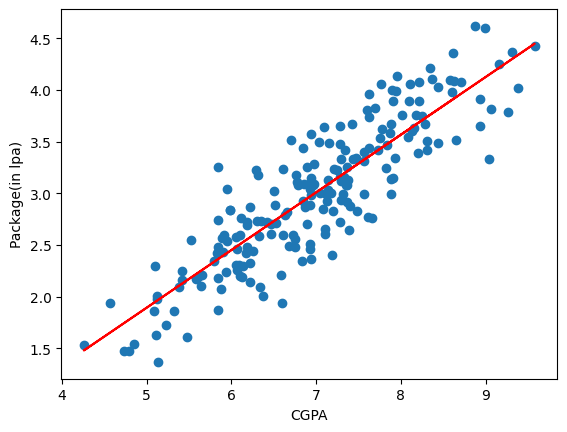

In [110]:
# Scatter plot of the data with the trained model's line of best fit displayed in red
plt.scatter(df['cgpa'], df['package'])
plt.plot(X_train, lr.predict(X_train), color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [111]:
# Import metrics from sklearn to evaluate model performance (MAE, MSE, and R2 score)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [112]:
# Generate target predictions for the unseen test inputs
y_pred = lr.predict(X_test)

In [113]:
# View the ground truth test targets as a simple array
y_test.values

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

In [114]:
# Calculate and print the Mean Absolute Error (MAE) of our predictions
print('MAE ->', mean_absolute_error(y_test, y_pred))

MAE -> 0.2884710931878175


In [115]:
# Calculate and print the Mean Squared Error (MSE) of our predictions
print('MSE ->', mean_squared_error(y_test, y_pred))

MSE -> 0.12129235313495527


In [116]:
# Calculate, print and store the R2 Score to determine the variance explained by the model
print('MSE ->', r2_score(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

MSE -> 0.780730147510384


In [117]:
# Check the dimensions of the testing set to obtain the sample count 'n'
# Adjusted R2 score
X_test.shape

(40, 1)

In [118]:
# Compute the Adjusted R2 score manually to account for the single independent feature
print('Adjusted R2 score ->', 1 - (((1-r2) * (40-1)) / (40-1-2)))

Adjusted R2 score -> 0.7688777230514858


In [119]:
# Create a copy of the dataset and append a completely random feature to observe the behavior of R2 and Adjusted R2
new_df1 = df.copy()
new_df1['random_feature'] = np.random.random(200)

new_df1 = new_df1[['cgpa','random_feature','package']]
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.403963,3.26
1,5.12,0.538673,1.98
2,7.82,0.293235,3.25
3,7.42,0.426119,3.67
4,6.94,0.657818,3.57


Text(0, 0.5, 'Package(in lpa)')

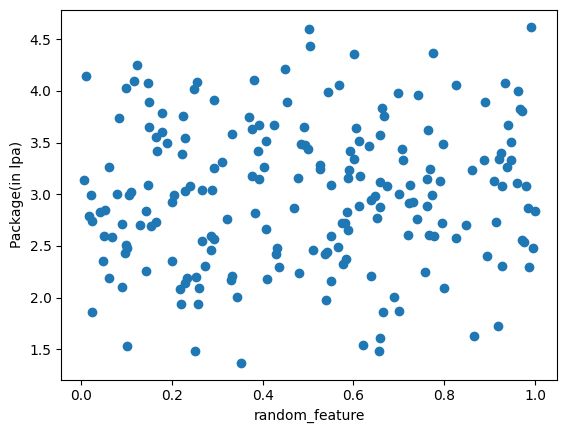

In [120]:
# Plot random_feature against package to visually verify that there is no correlation between them
plt.scatter(new_df1['random_feature'], new_df1['package'])
plt.xlabel('random_feature')
plt.ylabel('Package(in lpa)')

In [121]:
# Split features (including the random feature) and the target variable for multi-feature modeling
X = new_df1.iloc[:,0:2]
y = new_df1.iloc[:,-1]

In [122]:
# Split the modified random feature dataset into train and test groups
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [123]:
# Instantiate a Linear Regression object for multi-variable regression
lr = LinearRegression()

In [124]:
# Fit the regression model on the multi-feature training group
lr.fit(X_train, y_train)

LinearRegression()

In [125]:
# Predict package values on the testing subset incorporating the random feature
y_pred = lr.predict(X_test)

In [126]:
# Calculate and store the updated R2 score of the model with the added random feature
print('R2 Score ->', r2_score(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

R2 Score -> 0.7811713551918072


In [127]:
# Compute the manual Adjusted R2 score to demonstrate that adding a useless random feature decreases this value
print('Adjusted R2 Score ->', 1 - (((1-r2) * (40-1)) / (40-1-2)))

Adjusted R2 Score -> 0.7693427797967698


In [128]:
# Create another dataset copy and append a highly correlated feature ('iq') generated directly from package values
new_df2 = df.copy()

new_df2['iq'] = new_df2['package'] + (np.random.randint(-12,12,200) / 10)

new_df2 = new_df2[['cgpa','iq','package']]

In [129]:
# Print 5 random records to verify the newly created and highly correlated 'iq' feature values
new_df2.sample(5)

,cgpa,iq,package
115,8.35,4.91,4.21
81,6.10,1.30,2.20
124,6.06,3.41,2.31
191,7.28,2.58,3.48
90,7.11,3.06,2.66


Text(0, 0.5, 'Package(in lpa)')

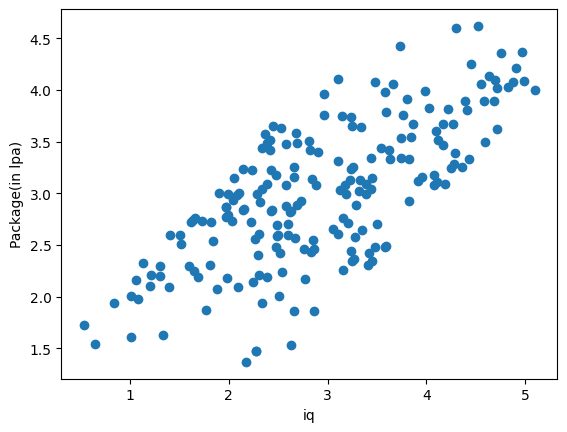

In [130]:
# Visualize the correlation between the engineered 'iq' feature and package using a scatter plot
plt.scatter(new_df2['iq'], new_df2['package'])
plt.xlabel('iq')
plt.ylabel('Package(in lpa)')

In [131]:
# Generate a single random integer between -100 and 100 for verification/debugging purposes
np.random.randint(-100, 100)

4

In [132]:
# Split features (CGPA and the highly correlated IQ) and the package targets for a multi-variable fit
X = new_df2.iloc[:,0:2]
y = new_df2.iloc[:,-1]

In [134]:
# Partition the correlated feature dataset into training and validation groups
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [135]:
# Train a linear regression model with the correlated features and execute predictions on the test group
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

In [136]:
# Calculate and store the R2 score to show how adding a useful feature significantly increases model performance
print('R2 Score ->', r2_score(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

R2 Score -> 0.8257455459700391


In [137]:
# Manually compute the Adjusted R2 score to demonstrate that a useful feature raises both R2 and Adjusted R2 scores
print('Adjusted R2 Score ->', 1 - (((1-r2) * (40-1)) / (40-1-2)))

Adjusted R2 Score -> 0.8163263862927439
